In [1]:
import pandas as pd
import numpy as np
sheet_id = "1PBQxpX3jQtuD92N9BcJtYxzCtPgyY3Y90bVBFPKbUmY"
gid = "1573075392"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
df1 = pd.read_csv(url, skiprows=9)
df1.to_csv("data/sysarmy_encuesta_2026_limpia.csv", index=False)


In [2]:
from src import EDA
from src.encoding import encode_data, encode_language
from src.train import split_data, number_estimators_model, tune_xgboost_hyperparameters, feature_importance, merge_data_for_full_train, bootstrap, calculate_confidence_intervals
from src.predictions import prediction, metrics

In [3]:
categories=['dedicacion',
       'recibis_algun_tipo_de_bono',
       'tuviste_actualizaciones_de_tus_ingresos_laborales_durante_el_ultimo_semestre',
       'trabajo_de',
       'anos_de_experiencia',
       'antiguedad_en_la_empresa_actual',
       'anos_en_el_puesto_actual',
       'cuantas_personas_tenes_a_cargo',
       'lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual',
       'tengo_edad',
       'sueldo_dolarizado',
       'seniority', '_sal']

In [4]:
df = df1[categories].copy()
EDA.clean_column_names(df)
EDA.check_nulls(df)


 amount of nulls per column DataFrame:
dedicacion                                                                      0
recibis_algun_tipo_de_bono                                                      0
tuviste_actualizaciones_de_tus_ingresos_laborales_durante_el_ultimo_semestre    0
trabajo_de                                                                      0
anos_de_experiencia                                                             0
antiguedad_en_la_empresa_actual                                                 0
anos_en_el_puesto_actual                                                        0
cuantas_personas_tenes_a_cargo                                                  0
lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual        1
tengo_edad                                                                      0
sueldo_dolarizado                                                               0
seniority                                                 

In [5]:
df=EDA.df_clean_salary_null(df,categories)

In [6]:
EDA.count_rows_with_any_null(df, name='modelado')


 amount of rows that have at least a NaN value: 1
    dedicacion recibis_algun_tipo_de_bono  \
441  full-time      de_uno_a_tres_sueldos   

    tuviste_actualizaciones_de_tus_ingresos_laborales_durante_el_ultimo_semestre  \
441                                                dos                             

             trabajo_de  anos_de_experiencia  antiguedad_en_la_empresa_actual  \
441  manager_/_director                   25                               10   

     anos_en_el_puesto_actual  cuantas_personas_tenes_a_cargo  \
441                         5                              50   

    lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual  \
441                                                NaN                         

     tengo_edad  sueldo_dolarizado seniority       _sal  
441          53               True    senior  5000000.0  


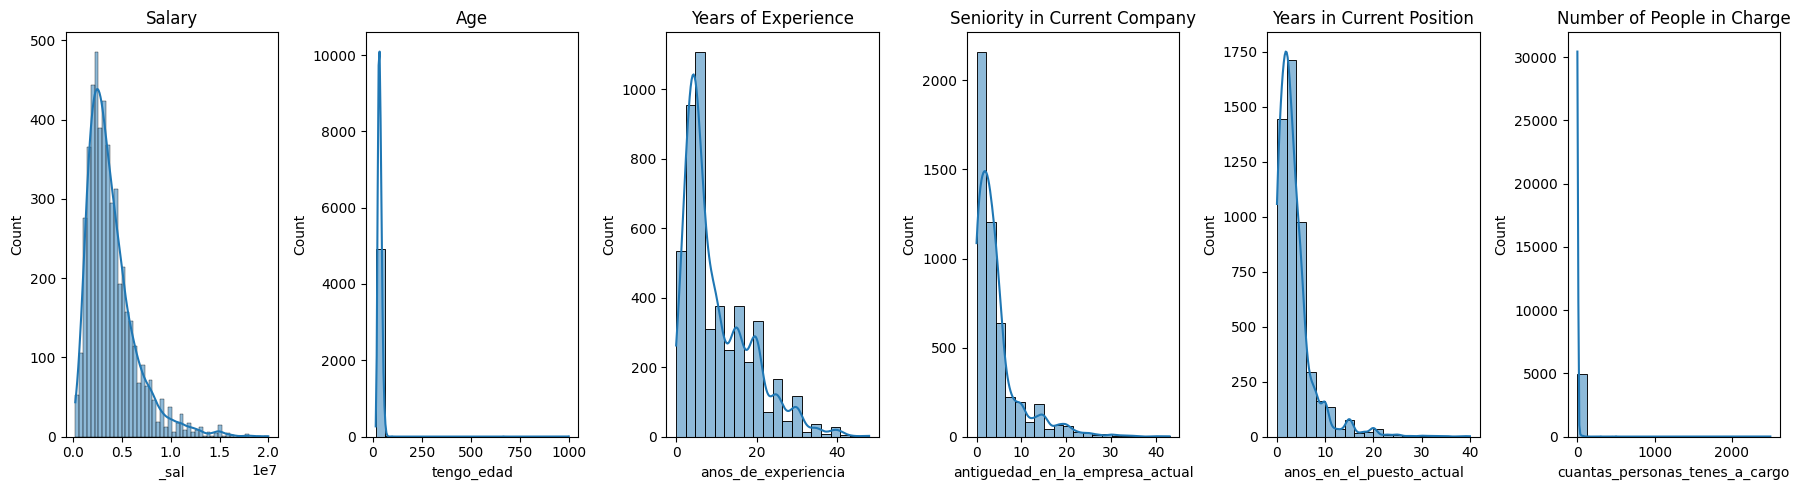

In [7]:
EDA.plot_distributions(df)

In [8]:
EDA.column_5_max_min_list(df, 'anos_de_experiencia')

5 Highest Anos De Experiencia:
3175    48
4051    48
4900    48
2629    45
4285    43
Name: anos_de_experiencia, dtype: int64

5 Lowest Anos De Experiencia:
174    0
318    0
380    0
389    0
443    0
Name: anos_de_experiencia, dtype: int64


In [9]:
EDA.column_5_max_min_list(df, 'antiguedad_en_la_empresa_actual')

5 Highest Antiguedad En La Empresa Actual:
4285    43
2379    42
1738    40
4337    40
1105    35
Name: antiguedad_en_la_empresa_actual, dtype: int64

5 Lowest Antiguedad En La Empresa Actual:
4    0
5    0
6    0
7    0
9    0
Name: antiguedad_en_la_empresa_actual, dtype: int64


In [10]:
EDA.column_5_max_min_list(df, 'anos_en_el_puesto_actual')

5 Highest Anos En El Puesto Actual:
2519    40
2674    39
4170    38
1105    35
1413    35
Name: anos_en_el_puesto_actual, dtype: int64

5 Lowest Anos En El Puesto Actual:
4     0
5     0
7     0
9     0
14    0
Name: anos_en_el_puesto_actual, dtype: int64


In [11]:
EDA.column_5_max_min_list(df, 'cuantas_personas_tenes_a_cargo')

5 Highest Cuantas Personas Tenes A Cargo:
3534    2500
4196     650
1500     500
3847     500
3987     500
Name: cuantas_personas_tenes_a_cargo, dtype: int64

5 Lowest Cuantas Personas Tenes A Cargo:
0    0
2    0
5    0
7    0
8    0
Name: cuantas_personas_tenes_a_cargo, dtype: int64


In [12]:
EDA.column_5_max_min_list(df, 'tengo_edad')

5 Highest Tengo Edad:
940     999
52      666
1068     99
1129     75
4370     75
Name: tengo_edad, dtype: int64

5 Lowest Tengo Edad:
3451    16
3557    18
4844    18
1579    19
2172    19
Name: tengo_edad, dtype: int64


In [13]:
df = df[df['tengo_edad']<90] 
 

In [14]:
columns_to_clean = ['anos_de_experiencia','anos_en_el_puesto_actual','cuantas_personas_tenes_a_cargo','antiguedad_en_la_empresa_actual']

for col in columns_to_clean:
    if col in df.columns:
        df = EDA.remove_outliers_percentil(df, col, percentil=0.95)

Columna 'anos_de_experiencia': Eliminando valores mayores a 27.00
Columna 'anos_en_el_puesto_actual': Eliminando valores mayores a 10.00
Columna 'cuantas_personas_tenes_a_cargo': Eliminando valores mayores a 9.00
Columna 'antiguedad_en_la_empresa_actual': Eliminando valores mayores a 13.00


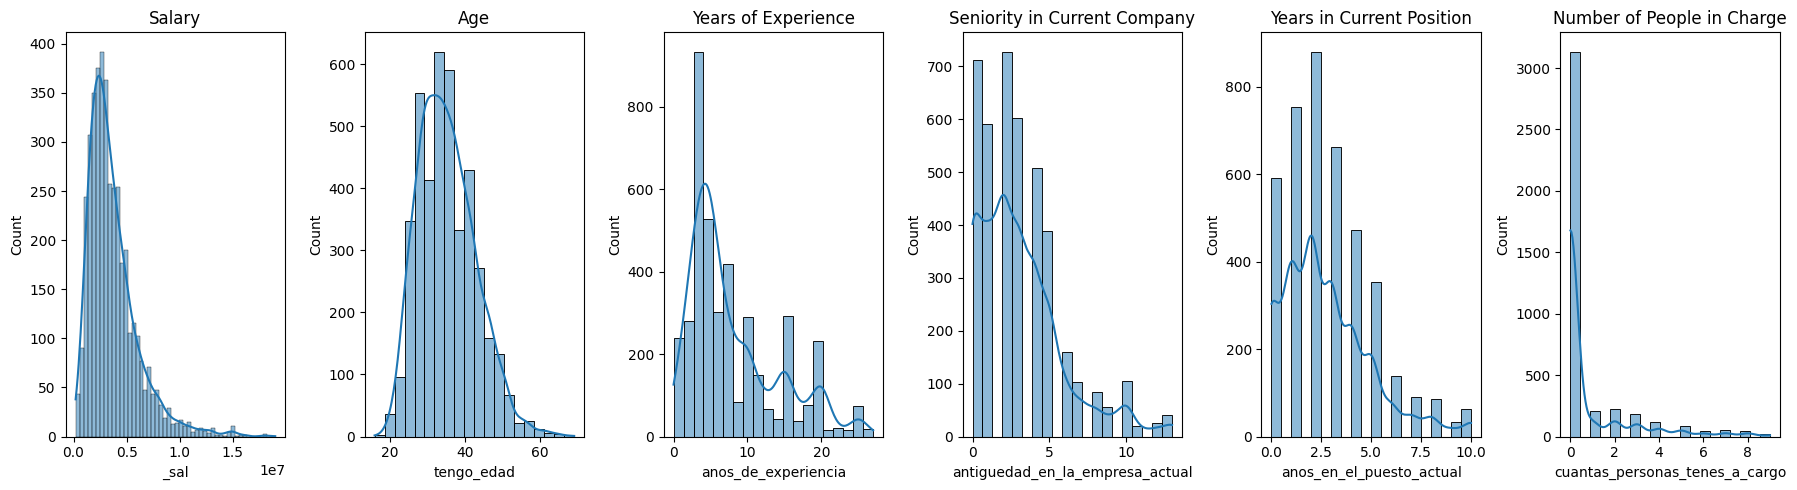

In [15]:
EDA.plot_distributions(df)

In [16]:
EDA.count_job_titles(df, threshold=10)


 Amount of rows with job titles that appear more than 10 times: 4014
 Job Titles with more than 10 repetitions:
trabajo_de
developer                    1542
sysadmin_/_devops_/_sre       459
technical_leader              247
manager_/_director            238
qa_/_tester                   216
bi_analyst_/_data_analyst     168
data_engineer                 132
ux/ui_designer                105
infosec                        98
architect                      96
data_scientist                 87
business_analyst               85
helpdesk                       78
consultant                     70
product_owner                  69
networking                     55
designer                       43
recruiter                      37
hrbp                           29
functional_analyst             28
sales_/_pre-sales              27
dba                            21
ux_researcher                  21
technical_support              20
scrum_master                   17
finance                   

In [17]:
EDA.count_dedication(df)


 Amount of rows with dedication levels:
dedicacion
full-time    3947
part-time     176
Name: count, dtype: int64


In [18]:
EDA.count_seniority(df)


 Amount of rows with seniority levels: 
seniority
senior         2139
semi-senior    1463
junior          521
Name: count, dtype: int64


In [19]:
EDA.salary_max_min_list(df)

5 Highest Salaries:
711     19000000.0
1028    18000000.0
1406    18000000.0
428     17940000.0
1064    16272000.0
Name: _sal, dtype: float64

5 Lowest Salaries:
1241    200000.0
1978    200000.0
2844    200000.0
4908    200000.0
1781    203000.0
Name: _sal, dtype: float64


In [20]:
df=EDA.remove_salary_outliers(df)

------------------------------
Clean  Outliers in '_sal':
Lower bound (5.0%): $1,100,000.00
Upper bound (95.0%): $8,200,000.00
Rows removed: 412 (9.99% of the dataset)
------------------------------


In [21]:
df = EDA.convert_salary_actualization_to_binary(df)
df = EDA.convert_dolarized_salary_to_int(df)


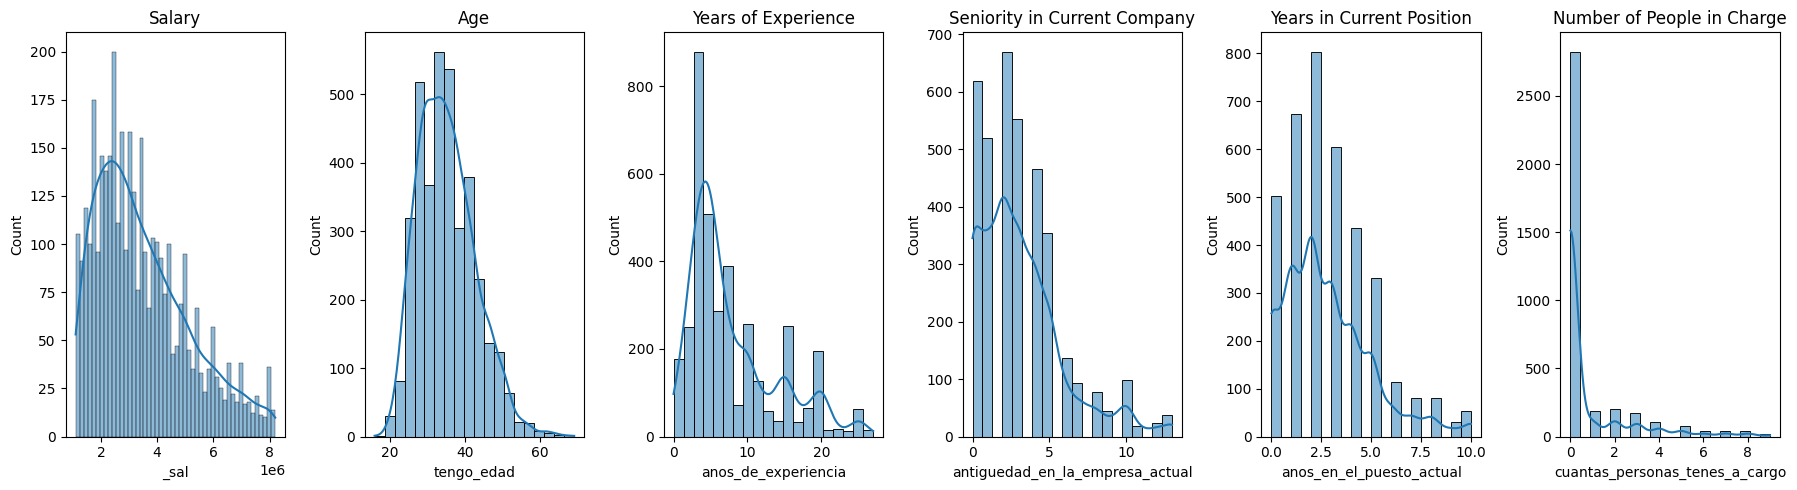

In [22]:
EDA.plot_distributions(df)

In [25]:
EDA.tipe_of_columns(df)


 data types of columns:
dedicacion                                                                       object
recibis_algun_tipo_de_bono                                                       object
tuviste_actualizaciones_de_tus_ingresos_laborales_durante_el_ultimo_semestre      int64
trabajo_de                                                                       object
anos_de_experiencia                                                               int64
antiguedad_en_la_empresa_actual                                                   int64
anos_en_el_puesto_actual                                                          int64
cuantas_personas_tenes_a_cargo                                                    int64
lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual         object
tengo_edad                                                                        int64
sueldo_dolarizado                                                                 int64
seniori

Encoding data for training model

In [23]:
df_encoded = encode_language(df)
df_encoded = encode_data(df_encoded)



In [24]:
df_train, df_val, df_test, y_train_log, y_val_log, y_test_log = split_data(df_encoded)

In [25]:
number_estimators= number_estimators_model(df_train, df_val,y_train_log, y_val_log)

[0]	validation_0-rmse:0.47231
[30]	validation_0-rmse:0.39545
[60]	validation_0-rmse:0.38458
[90]	validation_0-rmse:0.38151
[120]	validation_0-rmse:0.38084
[150]	validation_0-rmse:0.38033
[180]	validation_0-rmse:0.37982
[210]	validation_0-rmse:0.37893
[240]	validation_0-rmse:0.37878
[270]	validation_0-rmse:0.37876
[286]	validation_0-rmse:0.37868
The optimal number of estimators was: 236


In [26]:
df_full_train, y_full_log = merge_data_for_full_train(df_train, df_val, y_train_log, y_val_log)

In [27]:
model_xgb = tune_xgboost_hyperparameters(df_full_train, y_full_log, number_estimators, n_iterations=40)

Initializing hyperparameter search (40 iterations)...
Fitting 10 folds for each of 40 candidates, totalling 400 fits
------------------------------
¡Search completed!
Best hyperparameters found:
{'subsample': 0.7, 'n_estimators': 236, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


In [28]:
feature_importance(model_xgb, df_full_train)

Top 10 Variables por importance:
                        Variable  Importance
210             seniority_junior    0.091020
212             seniority_senior    0.059010
161          trabajo_de_helpdesk    0.034575
211        seniority_semi-senior    0.034182
2            anos_de_experiencia    0.031834
7              sueldo_dolarizado    0.030221
124         dedicacion_part-time    0.027740
197  trabajo_de_technical_leader    0.024503
123         dedicacion_full-time    0.023711
182       trabajo_de_qa_/_tester    0.023108


Check the model accuracy using the test DataFrame

In [29]:

y_pred_real = prediction(model_xgb, df_test)
y_test_real = np.expm1(y_test_log)
metrics(y_test_real, y_pred_real)
calculate_confidence_intervals(y_test_real, y_pred_real)

------------------------------
Mean Absolute Error: $973,282.76 pesos.
R2 Score: 0.40
Intervalo de confianza del 95% para MAE: $914,375.83 a $1,029,051.67
Intervalo de confianza del 95% para R2: 0.34 a 0.46


In [171]:
import joblib

joblib.dump(model_xgb, 'api_deployment/model_xgb.pkl')
joblib.dump(list(df_train.columns), 'api_deployment/columns.pkl')

print("Archives exported")

Archives exported
